In [1]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 4.1 MB/s eta 0:00:03
     ------ --------------------------------- 2.1/12.8 MB 4.7 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 5.0 MB/s eta 0:00:02
     ------------- -------------------------- 4.5/12.8 MB 5.2 MB/s eta 0:00:02
     ----------------- ---------------------- 5.5/12.8 MB 5.3 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 5.4 MB/s eta 0:00:02
     ------------------------ --------------- 7.9/12.8 MB 5.4 MB/s eta 0:00:01
     --------------------------- ------------ 8.9/12.8 MB 5.3 MB/s eta 0:00:01
     ------------------------------- -------- 10.2/12.8 MB 5.4 MB/s eta 0:00:01
     ---------------------------------- ----- 11.0/12.8 MB 5.5 MB/s eta 0:00:01
     ------------------------------------- -- 12.1/12.8 MB 5.2 M

In [2]:
!python ../preprocessing.py

Loading data...
Data quality check:
Shape: (27131, 12)
Total Papers: 27131
Total Columns: 12

Missing values per column:
id                 0
submitter          0
authors            0
title              0
comments       10158
journal-ref    24190
doi            24643
abstract           0
report-no      25780
categories         0
versions           0
year               0
dtype: int64

Duplicate IDs: 0

Duplicate Abstracts: 5

Empty Abstracts: 0

Short Abstracts (<10 words): 5

Year Range: 2007 to 2021
Papers per Year:
year
2007      87
2008     131
2009     197
2010     310
2011     547
2012     600
2013    1455
2014     854
2015    1014
2016    1622
2017    2521
2018    2844
2019    2775
2020    4344
2021    7830
Name: count, dtype: int64

Cleaning data...
After dropping missing abstracts: 27131 papers. So removed 0
After dropping duplicate IDs: 27131 papers. So removed 0
After dropping duplicate abstracts: 27126 papers. So removed 5
After dropping empty abstracts: 27126 papers. So rem

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\11873\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!

100%|██████████| 27121/27121 [01:13<00:00, 367.29it/s]


In [3]:
import sys
# I will add the upper level folder (..) to this search list
sys.path.append('..')

In [4]:
import re
import numpy as np
import pandas as pd

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA, TruncatedSVD, LatentDirichletAllocation
from sklearn.preprocessing import normalize

In [7]:
from tqdm import tqdm

In [8]:
df = pd.read_pickle("data_preprocessed.pkl")

In [9]:
print(f"Total number of filtered AI/ML/NLP papers: {len(df)}")

Total number of filtered AI/ML/NLP papers: 27121


In [10]:
display(df.head(3))

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions,year,cleaned_abstract,period
0,0704.1274,Dev Rajnarayan,David H. Wolpert and Dev G. Rajnarayan,Parametric Learning and Monte Carlo Optimization,None,None,None,This paper uncovers and explores the close r...,None,[cs.LG],[v1],2007,paper uncovers explores close relationship mon...,2007-2011
1,0704.1394,Tarik Had\v{z}i\'c,"Tarik Hadzic, Rune Moller Jensen, Henrik Reif ...",Calculating Valid Domains for BDD-Based Intera...,None,None,None,In these notes we formally describe the func...,None,[cs.AI],[v1],2007,notes formally describe functionality calculat...,2007-2011
2,0704.2010,Juliana Bernardes,"Juliana S Bernardes, Alberto Davila, Vitor San...",A study of structural properties on profiles HMMs,"6 pages, 7 figures",None,None,Motivation: Profile hidden Markov Models (pH...,None,[cs.AI],"[v1, v2]",2007,motivation profile hidden markov models phmms ...,2007-2011


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
# Now I will select the already cleaned summary column and will convert it into a list format to use in the TF-IDF model
abstracts = df['cleaned_abstract'].dropna().tolist()
# Unigrams
# I will remove the excessively common words that appear in more than 90% of articles
# Also, I will remove the rare words and typos that appear less than 5 times in 30,000 articles
# Then I will check the overall weight-to-word frequency ratio and will extract only the highest 15 features, in order to see the effect
tfidf_uni = TfidfVectorizer(stop_words='english', ngram_range=(1, 1), max_df=0.9, min_df=5, max_features=15)
tfidf_uni.fit(abstracts)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [13]:
print("The top 15 Unigrams with the highest frequency and weight:")
#  Here, I am displaying the results, which I selected from the 5,000 most important words
print(tfidf_uni.get_feature_names_out())

The top 15 Unigrams with the highest frequency and weight:
['approach' 'based' 'data' 'language' 'learning' 'model' 'models' 'neural'
 'paper' 'performance' 'propose' 'results' 'task' 'training' 'using']


In [14]:
# Bigrams
# I will remove the excessively common words that appear in more than 90% of articles
# Also, I will remove the rare words and typos that appear less than 5 times in 30,000 articles
# Then I will check the overall weight-to-word frequency ratio and will extract only the highest 15 features, in order to see the effect

tfidf_bi = TfidfVectorizer(stop_words='english', ngram_range=(2, 2), max_df=0.9, min_df=5, max_features=15)
tfidf_bi.fit(abstracts)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,'english'
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(2, ...)"


In [15]:
print("The top 15 Bigrams with the highest frequency and weight")
print(tfidf_bi.get_feature_names_out())

The top 15 Bigrams with the highest frequency and weight
['deep learning' 'experimental results' 'language models'
 'language processing' 'machine learning' 'machine translation'
 'natural language' 'neural network' 'neural networks' 'paper propose'
 'pre trained' 'real world' 'reinforcement learning' 'state art'
 'training data']


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# From the above results, I will make a note of all the common words, such as “paper” and “result”
# Mainly because they do not help to distinguish between research topics
academic_boilerplate = {
    'paper', 'propose', 'proposed', 'approach', 'method', 'methods', 
    'results', 'experimental', 'experiment', 'show', 'shows', 
    'using', 'based', 'performance', 'task', 'state', 'art' 
}

# Then, I will merge my custom vocabulary list with inbuilt English stopwords list
# This will basically help me to filter out the basic vocabulary
my_stop_words = list(ENGLISH_STOP_WORDS.union(academic_boilerplate))

# Now, I will run the upgraded bigram extractor
tfidf_bi_clean = TfidfVectorizer(
    stop_words=my_stop_words, 
    ngram_range=(2, 2), 
    max_df=0.9, 
    min_df=5, 
    max_features=15
)
tfidf_bi_clean.fit(abstracts)

print("15 Bigrams after cutting out the academic nonsense:")
# I will display the important words from the results
print(tfidf_bi_clean.get_feature_names_out())

15 Bigrams after cutting out the academic nonsense:
['deep learning' 'end end' 'language models' 'language processing'
 'large scale' 'machine learning' 'machine translation' 'natural language'
 'neural network' 'neural networks' 'pre trained' 'real world'
 'reinforcement learning' 'training data' 'word embeddings']


In [17]:
# Trigrams
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

academic_boilerplate = {
    'paper', 'propose', 'proposed', 'approach', 'method', 'methods', 
    'results', 'experimental', 'experiment', 'show', 'shows', 
    'using', 'based', 'performance', 'task', 'state', 'art' 
}

my_stop_words = list(ENGLISH_STOP_WORDS.union(academic_boilerplate))

# Now, I will run the upgraded trigram extractor
tfidf_tri = TfidfVectorizer(
    stop_words=my_stop_words,
    ngram_range=(3,3),
    max_df=0.9,
    min_df=5,
    max_features=15)

tfidf_tri.fit(abstracts)

print("The top 15 Trigrams with the highest frequency and weight")
print(tfidf_tri.get_feature_names_out())

The top 15 Trigrams with the highest frequency and weight
['deep learning models' 'deep neural networks' 'language processing nlp'
 'long short term' 'machine learning models' 'machine translation nmt'
 'named entity recognition' 'natural language processing'
 'natural language understanding' 'neural machine translation'
 'pre trained language' 'recurrent neural network'
 'recurrent neural networks' 'short term memory' 'trained language models']


In [18]:
academic_boilerplate = {
    'paper', 'propose', 'proposed', 'approach', 'method', 'methods', 
    'results', 'experimental', 'experiment', 'show', 'shows', 
    'using', 'based', 'performance', 'task', 'state', 'art'
}

# Here, I will configure the final TF-IDF vectorizer
tfidf_final = TfidfVectorizer(
    stop_words=list(academic_boilerplate), 
    ngram_range=(2,2),
    max_df=0.9,
    min_df=5,
    max_features=5000 # Keeping only the most important 5,000 features
)

X_tfidf = tfidf_final.fit_transform(abstracts)


In [19]:
print(f"The shape of the matrix: {X_tfidf.shape}")
print("We have 30529 papers and extract the 5000 most core two-word features for them")

The shape of the matrix: (27121, 5000)
We have 30529 papers and extract the 5000 most core two-word features for them


In [20]:
feature_names_final = tfidf_final.get_feature_names_out()

In [21]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score

In [22]:
# Extract real epoch labels
features = feature_names_final
periods = sorted(df['period'].unique())
period_labels = df['period'].values
# Normalize the TF-IDF matrix
X_norm = normalize(X_tfidf)

In [23]:
# Dynamically obtain the real period in the data
periods = sorted(df['period'].unique())
print(f"Successful detection of real periods: {periods}")

Successful detection of real periods: ['2007-2011', '2012-2016', '2017-2021']


In [24]:
centroids = {}
for p in periods:
    # Calculate the average of all paper vectors in the period
    centroids[p] = X_norm[period_labels == p].mean(axis=0)

In [25]:
# Print the top 15 absolutely dominant words of each era
for p in periods:
    mean_scores = np.asarray(centroids[p]).flatten()
    top_idx = mean_scores.argsort()[-15:][::-1]
    top_words = [features[i] for i in top_idx]
    print(f"【{p}】Dominant words: " + ", ".join(top_words))

【2007-2011】Dominant words: local search, machine learning, semantic web, natural language, artificial intelligence, well known, real world, logic programs, constraint satisfaction, logic programming, decision making, learning algorithm, answer set, constraint programming, polynomial time
【2012-2016】Dominant words: bayesian networks, machine learning, natural language, decision making, real world, artificial intelligence, neural network, machine translation, well known, neural networks, bayesian network, belief networks, knowledge base, language processing, first order
【2017-2021】Dominant words: machine learning, natural language, neural networks, neural network, deep learning, reinforcement learning, machine translation, real world, pre trained, language models, training data, language processing, large scale, question answering, end end


In [26]:
# Cosine Distance
# The closer the value is to 1, the greater the difference between the two periods; 
# the closer it is to 0, the more similar they are
for i, p1 in enumerate(periods):
    for p2 in periods[i+1:]:
        sim = cosine_similarity(np.asarray(centroids[p1]), np.asarray(centroids[p2]))[0][0]
        print(f"{p1} Comparison {p2}: Distance = {1 - sim:.4f}")

2007-2011 Comparison 2012-2016: Distance = 0.2595
2007-2011 Comparison 2017-2021: Distance = 0.5133
2012-2016 Comparison 2017-2021: Distance = 0.2889


In [27]:
# Silhouette score
# # Using the cosine metric, set `sample_size` to 3000 to ensure performance
score = silhouette_score(X_norm, period_labels, metric='cosine', sample_size=3000)
print(f"Silhouette score: {score:.4f}")

Silhouette score: 0.0015


In [28]:
!pip install xgboost

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [30]:
# To help the classifier converge more quickly, I will use the previously standardised X_norm
X = X_norm 
y = period_labels

In [31]:
print(f"Data size: {X.shape[0]} , {X.shape[1]} Features")

Data size: 27121 , 5000 Features


In [32]:
# Logistic Regression
# # Use `n_jobs=-1` to utilise all CPU cores for faster processing
lr = LogisticRegression(max_iter=1000, C=1.0, multi_class='multinomial', n_jobs=-1)
lr_scores = cross_val_score(lr, X, y, cv=3, scoring='f1_macro', n_jobs=-1)
print(f"LR macro average F1 score  (CV=3): {lr_scores.mean():.4f}")

LR macro average F1 score  (CV=3): 0.3978


In [33]:
# Top discriminative features per class
lr.fit(X, y)
for i, cls in enumerate(lr.classes_):
    coefs = lr.coef_[i]
    top_pos_idx = np.argsort(lr.coef_[i])[-10:][::-1]
    top_neg_idx = np.argsort(coefs)[:10]
    pos_words = [feature_names_final[j] for j in top_pos_idx]
    neg_words = [feature_names_final[j] for j in top_neg_idx]
    print(f"【{cls}】")
    print(f"  Strongly IN this period : {', '.join(pos_words)}")
    print(f"  Strongly OUT this period: {', '.join(neg_words)}")

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


【2007-2011】
  Strongly IN this period : planning competition, web services, language resources, global constraints, article presents, symmetry breaking, information system, adding new, recognition system, system capable
  Strongly OUT this period: deep learning, word embeddings, neural network, widely used, deep neural, sentiment analysis, end end, neural networks, reinforcement learning, training data
【2012-2016】
  Strongly IN this period : bayesian networks, possibility theory, influence diagram, recurrent neural, belief networks, influence diagrams, rough sets, bayesian network, possibilistic logic, part speech
  Strongly OUT this period: pre trained, graph neural, federated learning, self attention, fine tuning, data augmentation, code available, meta learning, covid 19, adversarial training
【2017-2021】
  Strongly IN this period : pre trained, deep learning, graph neural, federated learning, data augmentation, self attention, language models, code available, low resource, neural ne

In [34]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_scores = cross_val_score(rf, X, y, cv=3, scoring='f1_macro', n_jobs=-1)
print(f"RF macro average F1 score (CV=3): {rf_scores.mean():.4f}")

RF macro average F1 score (CV=3): 0.4230


In [35]:
rf.fit(X, y)
top_rf = np.argsort(rf.feature_importances_)[-15:][::-1]
rf_words = [features[i] for i in top_rf]
print("RF Top words:", [feature_names_final[i] for i in top_rf])

RF Top words: ['bayesian networks', 'deep learning', 'language models', 'pre trained', 'reinforcement learning', 'neural networks', 'natural language', 'bayesian network', 'machine learning', 'belief networks', 'neural network', 'end end', 'probabilistic inference', 'influence diagrams', 'data mining']


In [36]:
# XGBoost
le = LabelEncoder()
y_enc = le.fit_transform(period_labels)
xgb = XGBClassifier(n_estimators=100, n_jobs=-1, eval_metric='mlogloss', random_state=42)
xgb_scores = cross_val_score(xgb, X_norm, y_enc, cv=3, scoring='f1_macro')
print(f"XGBoost macro-averaged F1 score: {xgb_scores.mean():.4f}")

XGBoost macro-averaged F1 score: 0.3464


In [37]:
xgb.fit(X_norm, y_enc)
top_xgb = np.argsort(xgb.feature_importances_)[-15:][::-1]
print("XGBoost Top words:", [feature_names_final[i] for i in top_xgb])

XGBoost Top words: ['pre trained', 'belief networks', 'planning competition', 'bayesian networks', 'low resource', 'bayesian network', 'language models', 'semantic web', 'local search', 'fine tuning', 'belief network', 'extensive experiments', 'possibility theory', 'data augmentation', 'deep learning']


D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\11873\AppData\Local\Temp\ipykernel_6248\827395670.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs, y=top_words, ax=axes[i], palette="viridis")
C:\Users\11873\AppData\Local\Temp\ipykernel_6248\827395670.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs, y=top_words, ax=axes[i], palette="viridis")
C:\Users\11873\AppData\Local\Temp\ipykernel_6248\827395670.py:15: FutureWarning: 

Pa

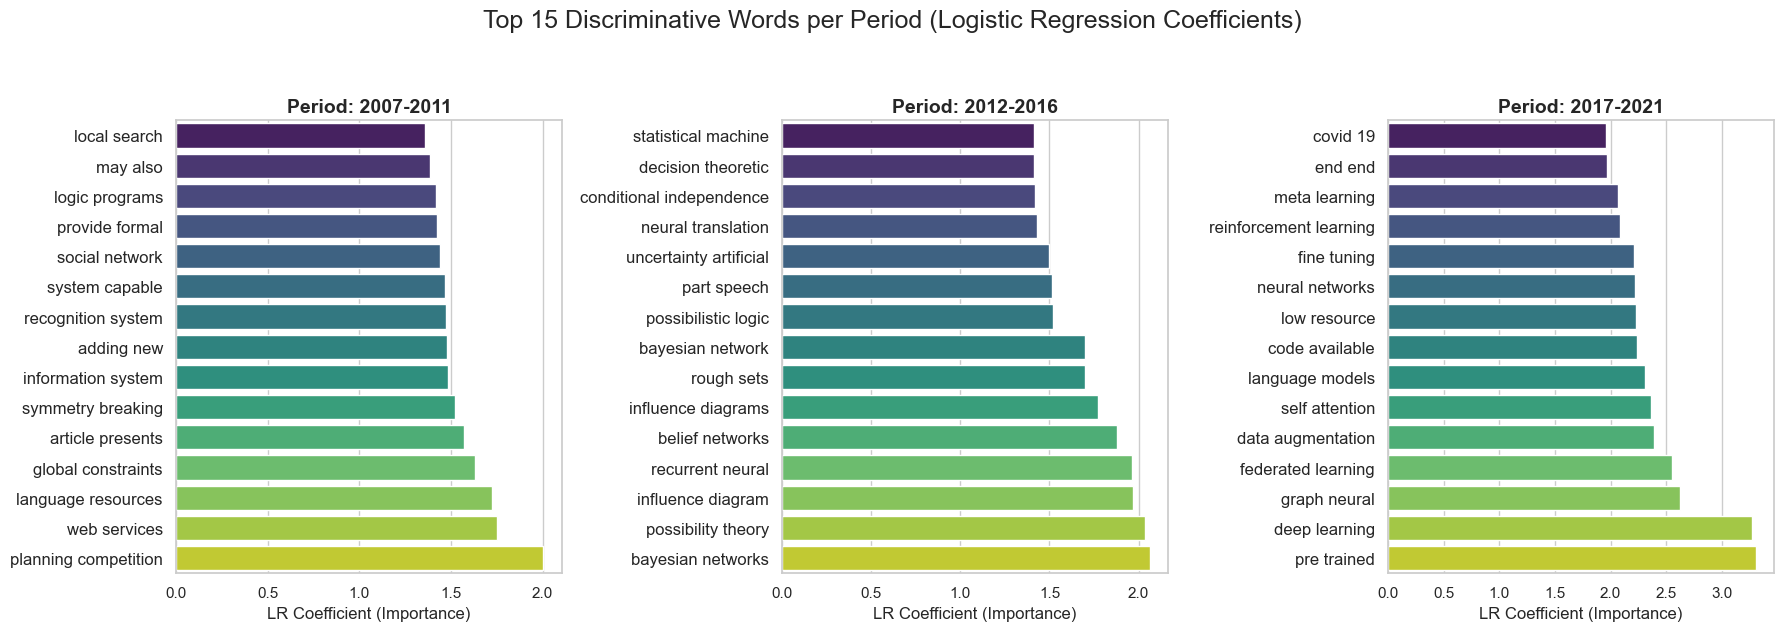

In [38]:
# Bar Charts & Heatmap
sns.set_theme(style="whitegrid")
lr.fit(X_norm, period_labels)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)
fig.suptitle('Top 15 Discriminative Words per Period (Logistic Regression Coefficients)', fontsize=18, y=1.05)

for i, cls in enumerate(lr.classes_):
    coefs = lr.coef_[i]
    # Take the top 15 most important words
    top_idx = np.argsort(coefs)[-15:]
    top_words = [features[j] for j in top_idx]
    top_coefs = coefs[top_idx]
    
    # Draw a bar chart
    sns.barplot(x=top_coefs, y=top_words, ax=axes[i], palette="viridis")
    axes[i].set_title(f'Period: {cls}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('LR Coefficient (Importance)', fontsize=12)
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

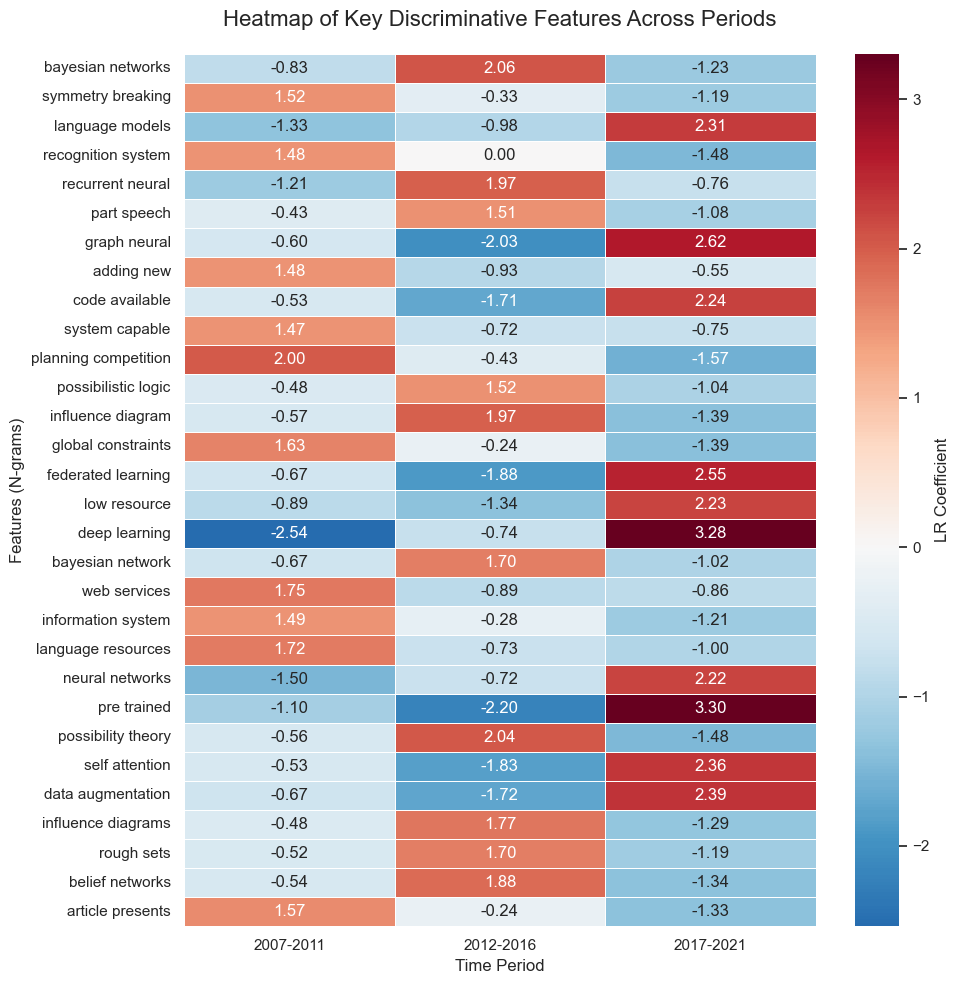

In [39]:
# Heatmap
# Select the top 10 words from each era, merge them after removing duplicates, 
# and display how their relative importance has changed across the three eras
top_words_set = set()
for i in range(len(lr.classes_)):
    top_idx = np.argsort(lr.coef_[i])[-10:]
    for j in top_idx:
        top_words_set.add(features[j])

top_words_list = list(top_words_set)

# Build a data matrix for a heat map
heatmap_data = []
for word in top_words_list:
    word_idx = np.where(features == word)[0][0]
    heatmap_data.append(lr.coef_[:, word_idx])

heatmap_df = pd.DataFrame(heatmap_data, index=top_words_list, columns=lr.classes_)

# Draw heat map
plt.figure(figsize=(10, 10))
sns.heatmap(heatmap_df, cmap="RdBu_r", center=0, annot=True, fmt=".2f", 
            linewidths=.5, cbar_kws={"label": "LR Coefficient"})
plt.title('Heatmap of Key Discriminative Features Across Periods', fontsize=16, pad=20)
plt.ylabel('Features (N-grams)', fontsize=12)
plt.xlabel('Time Period', fontsize=12)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

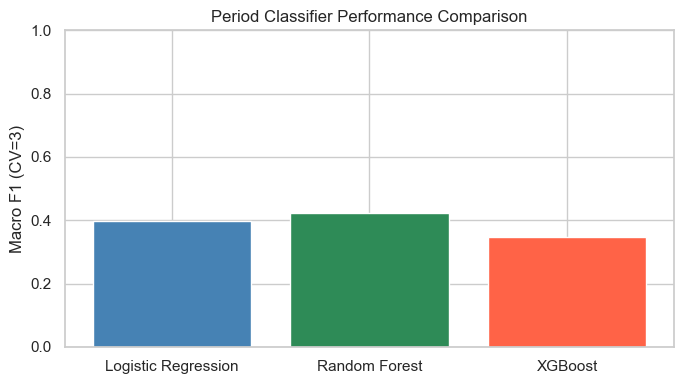

In [40]:
# Comparison chart of F1 scores for the three models
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
scores = [lr_scores.mean(), rf_scores.mean(), xgb_scores.mean()]

plt.figure(figsize=(7, 4))
plt.bar(models, scores, color=['steelblue', 'seagreen', 'tomato'])
plt.ylim(0, 1)
plt.ylabel("Macro F1 (CV=3)")
plt.title("Period Classifier Performance Comparison")
plt.tight_layout()
plt.show()

In [41]:
# === EXPORTS FOR INTEGRATION NOTEBOOK ===
import json
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# 1. Centroid cosine distances between CONSECUTIVE periods
# periods is already sorted: ['2007-2011', '2012-2016', '2017-2021']
tfidf_distances = []
for i in range(len(periods) - 1):
    c1 = np.asarray(centroids[periods[i]]).flatten().reshape(1, -1)
    c2 = np.asarray(centroids[periods[i+1]]).flatten().reshape(1, -1)
    dist = 1 - cosine_similarity(c1, c2)[0][0]
    tfidf_distances.append(round(float(dist), 6))
np.save('tfidf_centroid_distances.npy', tfidf_distances)
print("Distances saved:", tfidf_distances)  # verify it's [d1, d2]

# 2. Silhouette score (already computed as score)
np.save('tfidf_silhouette.npy', np.array([score]))
print("Silhouette saved:", score)

# 3. LR top discriminative words per period — re-fit and export
lr.fit(X_norm, period_labels)
rows = []
for i, cls in enumerate(lr.classes_):
    top_pos_idx = np.argsort(lr.coef_[i])[-15:][::-1]
    top_neg_idx = np.argsort(lr.coef_[i])[:15]
    for idx in top_pos_idx:
        rows.append({'word': feature_names_final[idx], 'coefficient': lr.coef_[i][idx], 'period': cls, 'direction': 'positive'})
    for idx in top_neg_idx:
        rows.append({'word': feature_names_final[idx], 'coefficient': lr.coef_[i][idx], 'period': cls, 'direction': 'negative'})
pd.DataFrame(rows).to_csv('classifier_top_words.csv', index=False)
print("Classifier words saved.")

Distances saved: [0.259486, 0.288921]
Silhouette saved: 0.00154135269440121


D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classifier words saved.
